========== DATASET OVERVIEW ==========
Training Data Shape: (891, 12)
Test Data Shape    : (418, 11)

Missing Values Per Column:
             Missing Values
PassengerId               0
Survived                  0
Pclass                    0
Name                      0
Sex                       0
Age                     177
SibSp                     0
Parch                     0
Ticket                    0
Fare                      0
Cabin                   687
Embarked                  2

========== TITANIC DATA DICTIONARY ==========


,Column,Meaning,Values
0,PassengerId,Unique ID,-
1,Survived,Survival status,"0 = No, 1 = Yes"
2,Pclass,Passenger class,"1 = 1st, 2 = 2nd, 3 = 3rd"
3,Name,Passenger name,-
4,Sex,Gender,"male, female"
5,Age,Age in years,Some missing
6,SibSp,Siblings / spouses aboard,-
7,Parch,Parents / children aboard,-
8,Ticket,Ticket number,-
9,Fare,Ticket price,-


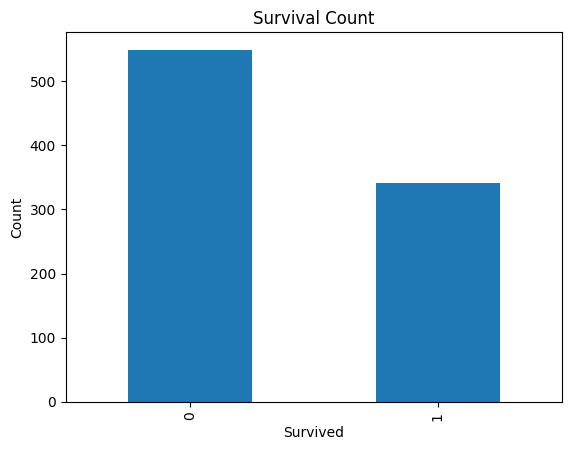

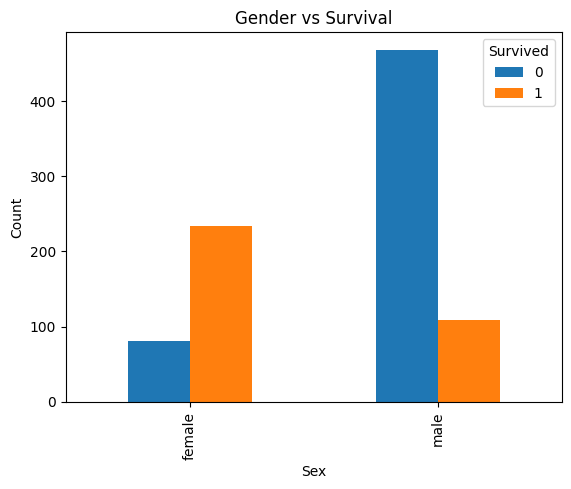

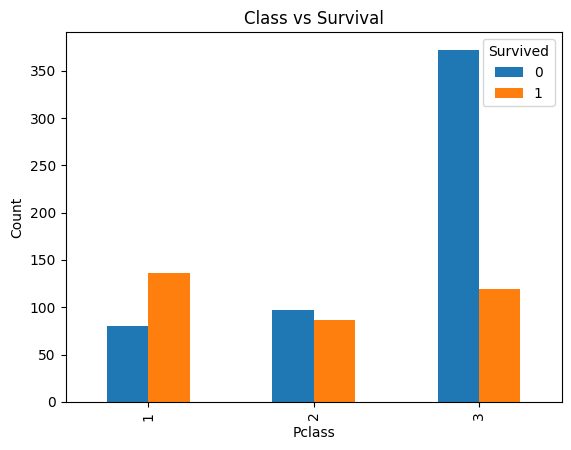


Preprocessing completed.
- Age missing values filled with mean
- Embarked missing values filled with mode
- Fare missing values in test filled with mean
- Cabin column dropped because too many values were missing

Training set shape: (712, 9)
Validation set shape: (179, 9)

All 3 models trained successfully.

Hyperparameter tuning completed.
Best Parameters: {'max_depth': 4, 'n_estimators': 100}

        MODEL RESULTS SUMMARY

Best Parameters from GridSearchCV:
{'max_depth': 4, 'n_estimators': 100}

Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression      0.80       0.79    0.65      0.71
      Decision Tree      0.77       0.75    0.58      0.66
      Random Forest      0.83       0.80    0.74      0.77
Tuned Random Forest      0.81       0.86    0.61      0.71

Best Model:
Model    : Random Forest
Accuracy : 0.83
Precision: 0.80
Recall   : 0.74
F1-Score : 0.77


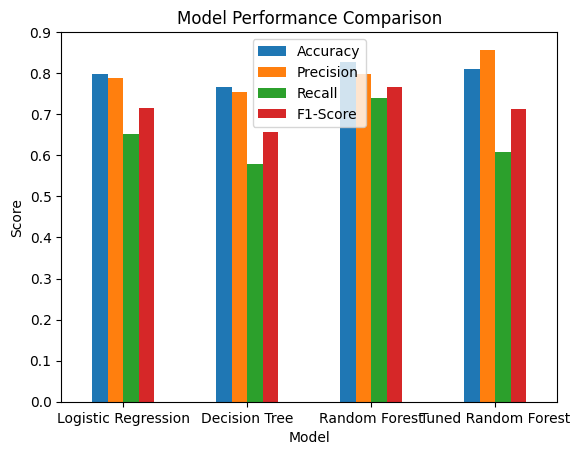


Confusion Matrix (Best Model):


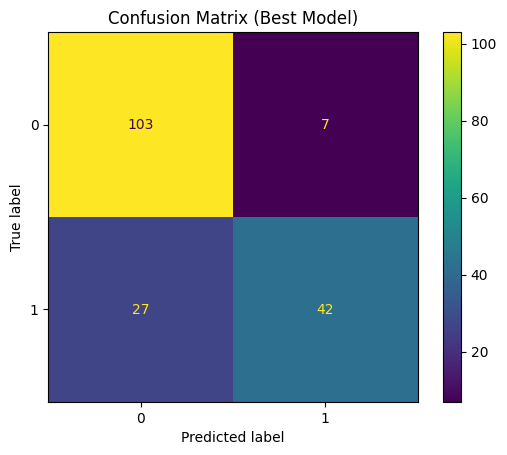


Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       110
           1       0.86      0.61      0.71        69

    accuracy                           0.81       179
   macro avg       0.82      0.77      0.79       179
weighted avg       0.82      0.81      0.80       179



In [3]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# ===============================
# 2. Load Dataset
# ===============================
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("========== DATASET OVERVIEW ==========")
print("Training Data Shape:", train.shape)
print("Test Data Shape    :", test.shape)

print("\nMissing Values Per Column:")
print(train.isnull().sum().to_frame(name="Missing Values").to_string())

# ===============================
# 3. Titanic Data Dictionary
# ===============================
data_dictionary = pd.DataFrame({
    "Column": [
        "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
        "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"
    ],
    "Meaning": [
        "Unique ID",
        "Survival status",
        "Passenger class",
        "Passenger name",
        "Gender",
        "Age in years",
        "Siblings / spouses aboard",
        "Parents / children aboard",
        "Ticket number",
        "Ticket price",
        "Cabin number",
        "Port of embarkation"
    ],
    "Values": [
        "-",
        "0 = No, 1 = Yes",
        "1 = 1st, 2 = 2nd, 3 = 3rd",
        "-",
        "male, female",
        "Some missing",
        "-",
        "-",
        "-",
        "-",
        "Many missing",
        "C, Q, S"
    ]
})

print("\n========== TITANIC DATA DICTIONARY ==========")
display(data_dictionary)

data_dictionary.to_csv("titanic_data_dictionary.csv", index=False)

# ===============================
# 4. EDA (Exploratory Data Analysis)
# ===============================
train['Survived'].value_counts().plot(kind='bar', title='Survival Count')
plt.ylabel("Count")
plt.show()

pd.crosstab(train['Sex'], train['Survived']).plot(kind='bar', title='Gender vs Survival')
plt.ylabel("Count")
plt.show()

pd.crosstab(train['Pclass'], train['Survived']).plot(kind='bar', title='Class vs Survival')
plt.ylabel("Count")
plt.show()

# ===============================
# 5. Data Preprocessing
# ===============================
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True, dtype=float)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True, dtype=float)

train['FamilySize'] = train['SibSp'] + train['Parch']
test['FamilySize'] = test['SibSp'] + test['Parch']

test_ids = test['PassengerId']

drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

print("\nPreprocessing completed.")
print("- Age missing values filled with mean")
print("- Embarked missing values filled with mode")
print("- Fare missing values in test filled with mean")
print("- Cabin column dropped because too many values were missing")

# ===============================
# 6. Split Data
# ===============================
X = train.drop('Survived', axis=1)
y = train['Survived']

X = X.astype(float)
test = test.astype(float)

X = X.replace([np.inf, -np.inf], np.nan)
test = test.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.mean())
test = test.fillna(test.mean())

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)

# ===============================
# 7. Train Models
# ===============================
# Model 1: Logistic Regression
log_model = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
    C=0.5,
    random_state=42
)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_val)

# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_val)

# Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

print("\nAll 3 models trained successfully.")

# ===============================
# 8. Hyperparameter Tuning
# ===============================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, 8]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3
)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_val)

print("\nHyperparameter tuning completed.")
print("Best Parameters:", grid.best_params_)

# ===============================
# 9. Predict Test Data
# ===============================
final_predictions = best_rf.predict(test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': final_predictions
})

submission.to_csv('submission.csv', index=False)

# ===============================
# 10. Evaluation Summary
# ===============================
log_acc = accuracy_score(y_val, y_pred_log)
dt_acc = accuracy_score(y_val, y_pred_dt)
rf_acc = accuracy_score(y_val, y_pred_rf)
best_acc = accuracy_score(y_val, y_pred_best)

log_precision = precision_score(y_val, y_pred_log)
dt_precision = precision_score(y_val, y_pred_dt)
rf_precision = precision_score(y_val, y_pred_rf)
best_precision = precision_score(y_val, y_pred_best)

log_recall = recall_score(y_val, y_pred_log)
dt_recall = recall_score(y_val, y_pred_dt)
rf_recall = recall_score(y_val, y_pred_rf)
best_recall = recall_score(y_val, y_pred_best)

log_f1 = f1_score(y_val, y_pred_log)
dt_f1 = f1_score(y_val, y_pred_dt)
rf_f1 = f1_score(y_val, y_pred_rf)
best_f1 = f1_score(y_val, y_pred_best)

# ===============================
# 11. Clean Output Section
# ===============================
print("\n===================================")
print("        MODEL RESULTS SUMMARY")
print("===================================")

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [log_acc, dt_acc, rf_acc, best_acc],
    'Precision': [log_precision, dt_precision, rf_precision, best_precision],
    'Recall': [log_recall, dt_recall, rf_recall, best_recall],
    'F1-Score': [log_f1, dt_f1, rf_f1, best_f1]
})

print("\nBest Parameters from GridSearchCV:")
print(grid.best_params_)

print("\nModel Comparison Table:")
print(results.round(2).to_string(index=False))

best_model = results.loc[results['Accuracy'].idxmax()]

print("\nBest Model:")
print(f"Model    : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.2f}")
print(f"Precision: {best_model['Precision']:.2f}")
print(f"Recall   : {best_model['Recall']:.2f}")
print(f"F1-Score : {best_model['F1-Score']:.2f}")

# ===============================
# 12. Visualization
# ===============================
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    title='Model Performance Comparison',
    rot=0
)
plt.ylabel("Score")
plt.show()

print("\nConfusion Matrix (Best Model):")
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Best Model)")
plt.show()

print("\nClassification Report (Best Model):")
print(classification_report(y_val, y_pred_best))


